In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("../data/application_train.csv")
test_data = pd.read_csv("../data/application_test.csv")
# df = pd.concat([train_data, test_data], ignore_index=True)

In [62]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [23]:
df.sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
20509,123919,0.0,Cash loans,M,N,Y,0,270000.0,272520.0,21528.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
128897,249510,0.0,Cash loans,F,N,Y,0,382500.0,1076247.0,72936.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
20858,124307,0.0,Cash loans,F,N,Y,0,81000.0,544491.0,17694.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
267318,409715,0.0,Cash loans,M,N,N,0,135000.0,247275.0,19417.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
71882,183354,0.0,Cash loans,F,N,Y,0,112500.0,183294.0,8073.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,5.0


In [24]:
df.shape

(356255, 122)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(40), object(16)
memory usage: 331.6+ MB


In [26]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("Duplicate rows:", df.duplicated().sum())

COMMONAREA_AVG              248360
COMMONAREA_MODE             248360
COMMONAREA_MEDI             248360
NONLIVINGAPARTMENTS_AVG     246861
NONLIVINGAPARTMENTS_MODE    246861
                             ...  
EXT_SOURCE_2                   668
AMT_GOODS_PRICE                278
AMT_ANNUITY                     36
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 68, dtype: int64
Duplicate rows: 0


In [18]:
#there is no duplicated rows 

In [27]:
(df.isna().mean() * 100).sort_values(ascending=False) #Pourcentage

COMMONAREA_AVG              69.714109
COMMONAREA_MODE             69.714109
COMMONAREA_MEDI             69.714109
NONLIVINGAPARTMENTS_AVG     69.293343
NONLIVINGAPARTMENTS_MODE    69.293343
                              ...    
NAME_HOUSING_TYPE            0.000000
NAME_FAMILY_STATUS           0.000000
NAME_EDUCATION_TYPE          0.000000
NAME_INCOME_TYPE             0.000000
SK_ID_CURR                   0.000000
Length: 122, dtype: float64

In [30]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    print(
        column,
        "min:", df[column].min(),
        "max:", df[column].max()
    )

SK_ID_CURR min: 100001 max: 456255
TARGET min: 0.0 max: 1.0
CNT_CHILDREN min: 0 max: 20
AMT_INCOME_TOTAL min: 25650.0 max: 117000000.0
AMT_CREDIT min: 45000.0 max: 4050000.0
AMT_ANNUITY min: 1615.5 max: 258025.5
AMT_GOODS_PRICE min: 40500.0 max: 4050000.0
REGION_POPULATION_RELATIVE min: 0.0002529999999999 max: 0.072508
DAYS_BIRTH min: -25229 max: -7338
DAYS_EMPLOYED min: -17912 max: 365243
DAYS_REGISTRATION min: -24672.0 max: 0.0
DAYS_ID_PUBLISH min: -7197 max: 0
OWN_CAR_AGE min: 0.0 max: 91.0
FLAG_MOBIL min: 0 max: 1
FLAG_EMP_PHONE min: 0 max: 1
FLAG_WORK_PHONE min: 0 max: 1
FLAG_CONT_MOBILE min: 0 max: 1
FLAG_PHONE min: 0 max: 1
FLAG_EMAIL min: 0 max: 1
CNT_FAM_MEMBERS min: 1.0 max: 21.0
REGION_RATING_CLIENT min: 1 max: 3
REGION_RATING_CLIENT_W_CITY min: -1 max: 3
HOUR_APPR_PROCESS_START min: 0 max: 23
REG_REGION_NOT_LIVE_REGION min: 0 max: 1
REG_REGION_NOT_WORK_REGION min: 0 max: 1
LIVE_REGION_NOT_WORK_REGION min: 0 max: 1
REG_CITY_NOT_LIVE_CITY min: 0 max: 1
REG_CITY_NOT_WORK_CITY 

In [31]:
#The ranges show that the dataset contains binary flags, normalized values, 
# and financial variables with very different scales. Several extreme values—such as an income of 117 million,
# 20 children, and 261 credit inquiries—may be outliers. Negative day values represent time before the application,
# while `DAYS_EMPLOYED = 365243` is likely a missing-value placeholder. 
# These issues should be investigated and treated before modeling.

In [33]:
df["TARGET"].value_counts(dropna=False)
df["TARGET"].value_counts(normalize=True)

TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64

In [37]:
# 0: 91.93% of clients repaid without serious difficulty
# 1: 8.07% of clients had payment difficulties

In [39]:
correlations = (
    df.select_dtypes(include="number")
      .corr()["TARGET"]
      .sort_values()
)

print(correlations)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
                                 ...   
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, Length: 106, dtype: float64


In [63]:
print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all").T)

display(
    pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "unique_values": df.nunique()
    }).sort_values("missing_percent", ascending=False)
)

print("Duplicates:", df.duplicated().sum())

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,NaN,NaN,NaN,0.007,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,NaN,NaN,NaN,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,NaN,NaN,NaN,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,NaN,NaN,NaN,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


,dtype,missing_count,missing_percent,unique_values
COMMONAREA_MEDI,float64,214865,69.872297,3202
COMMONAREA_AVG,float64,214865,69.872297,3181
COMMONAREA_MODE,float64,214865,69.872297,3128
NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963,167
NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963,386
...,...,...,...,...
NAME_HOUSING_TYPE,object,0,0.000000,6
NAME_FAMILY_STATUS,object,0,0.000000,6
NAME_EDUCATION_TYPE,object,0,0.000000,5
NAME_INCOME_TYPE,object,0,0.000000,8


Duplicates: 0


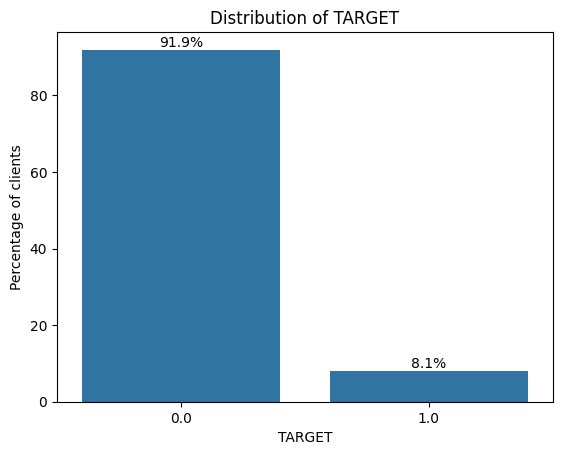

In [55]:
target_pct = df["TARGET"].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=target_pct.index, y=target_pct.values)
ax.set(
    title="Distribution of TARGET",
    xlabel="TARGET",
    ylabel="Percentage of clients"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [44]:
# Most clients belong to class 0, while only 8.07% belong to class 1. This indicates a strong class imbalance

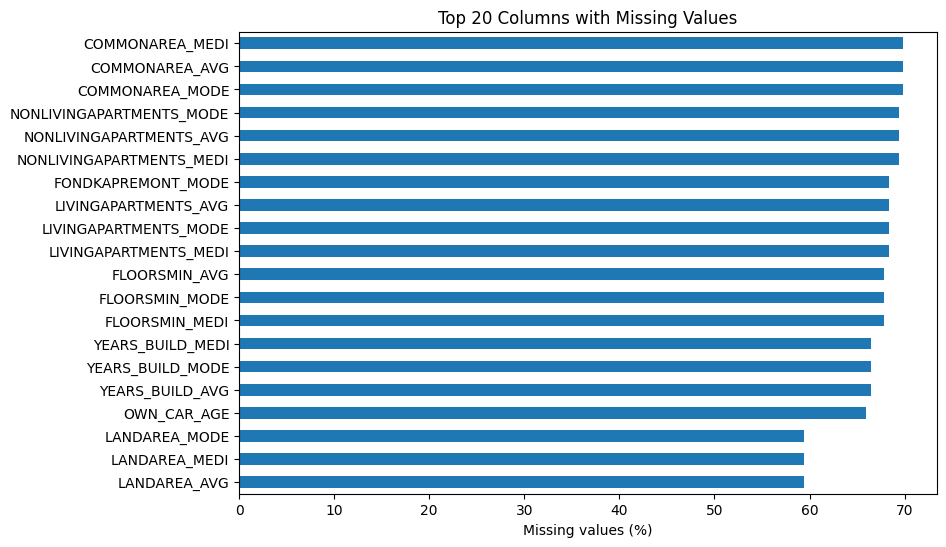

In [45]:
missing_pct = (
    train_data.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(20)
)

missing_pct.sort_values().plot(kind="barh", figsize=(9, 6))
plt.xlabel("Missing values (%)")
plt.title("Top 20 Columns with Missing Values")
plt.show()

In [46]:
# Several housing-related features contain more than 60% missing data and may require removal or careful imputation

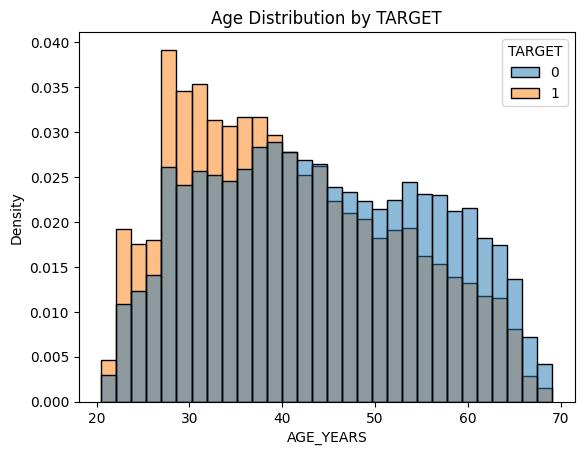

In [47]:
train_data["AGE_YEARS"] = -train_data["DAYS_BIRTH"] / 365.25

sns.histplot(
    data=train_data,
    x="AGE_YEARS",
    hue="TARGET",
    bins=30,
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by TARGET")
plt.show()

In [48]:
# This graph shows whether clients with payment difficulties tend to be younger or older

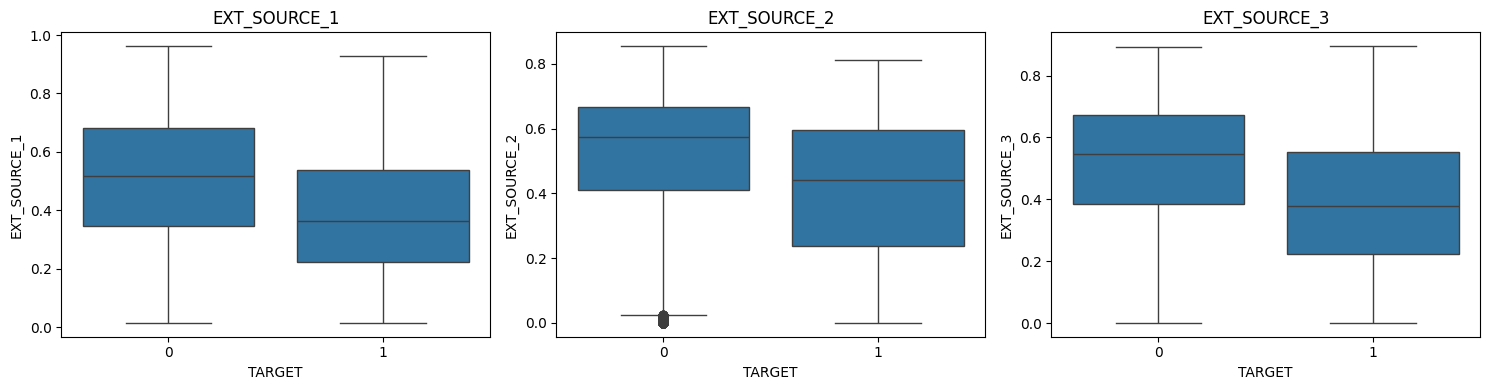

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"], axes
):
    sns.boxplot(data=train_data, x="TARGET", y=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [50]:
# These are the numerical variables most strongly correlated with TARGET.
# Lower external scores appear to be associated with greater payment difficulty

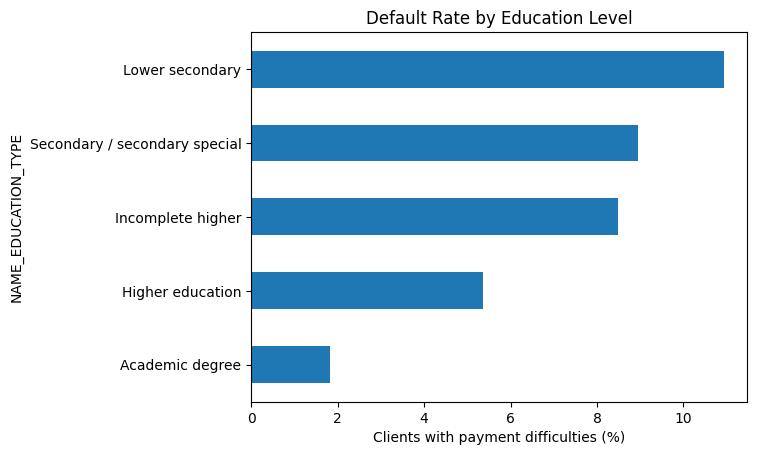

In [51]:
default_rate = (
    train_data.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
    .sort_values()
)

(default_rate * 100).plot(kind="barh")
plt.xlabel("Clients with payment difficulties (%)")
plt.title("Default Rate by Education Level")
plt.show()

In [52]:
# This plot compares the percentage of clients with payment difficulties across education levels.
#     A longer bar represents a higher default rate, suggesting greater credit risk within that group.
#     The graph shows an association between education and repayment behavior, 
# but it does not prove that education directly causes payment difficulties. 
#     Group sizes should also be checked before drawing conclusions

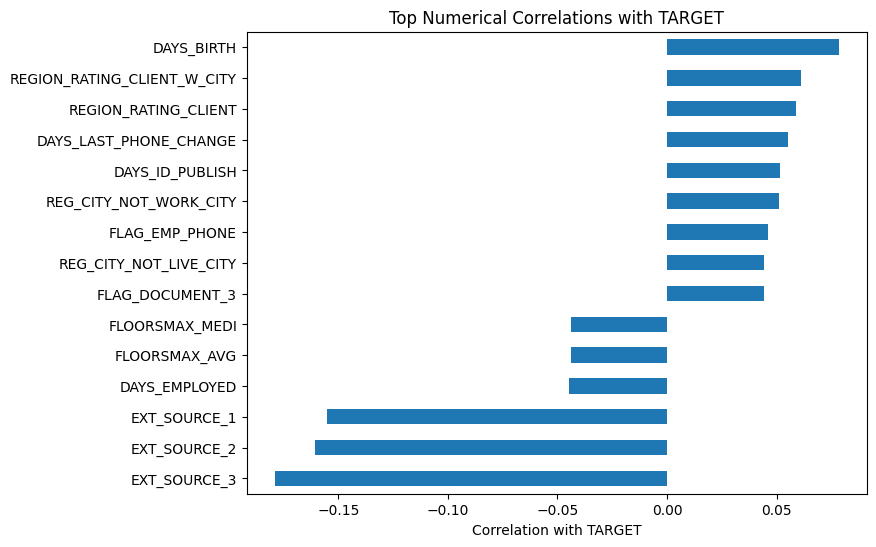

In [56]:
correlations = (
    df.select_dtypes(include="number")
      .corr()["TARGET"]
      .drop(["TARGET", "SK_ID_CURR"])
)

top_correlations = correlations.abs().nlargest(15).index

correlations.loc[top_correlations].sort_values().plot(
    kind="barh", figsize=(8, 6)
)
plt.xlabel("Correlation with TARGET")
plt.title("Top Numerical Correlations with TARGET")
plt.show()

In [57]:
education_summary = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
      .agg(client_count="size", default_rate="mean")
)

education_summary["default_rate_%"] = (
    education_summary["default_rate"] * 100
)

display(
    education_summary.sort_values("default_rate_%", ascending=False)
)

,client_count,default_rate,default_rate_%
NAME_EDUCATION_TYPE,,,
Lower secondary,4291,0.109277,10.927673
Secondary / secondary special,252379,0.089399,8.939929
Incomplete higher,12001,0.084850,8.484966
Higher education,87379,0.053551,5.355115
Academic degree,205,0.018293,1.829268


In [66]:
The dataset contains 307,511 loan applications and 122 variables.
    The target is highly imbalanced, with only 8.07% of clients experiencing payment difficulties. 
        Several housing variables contain substantial missing data, and some numerical variables contain anomalies or extreme values. Age, external credit scores, income, and education show associations with repayment behavior. These findings will guide missing-value treatment, feature engineering, and model evaluation

SyntaxError: invalid syntax (3656815153.py, line 3)